Flight Ticket Price Prediction Project

This project analyzes and predicts flight ticket prices
using Machine Learning techniques.

Features:
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Data Visualization
4. Feature Engineering
5. Flight Price Prediction using Regression

Author: Disha Kataria


**dataset link : https://drive.google.com/file/d/1Po3AI4VyyXHiT9rbCM1AB3xYglymb8Wj/view?usp=sharing**

# Project Objective :

The objective of this project is to analyze
different factors affecting flight ticket prices
and build a machine learning model to predict prices.

In [ ]:
Import Libraries

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset
df = pd.read_csv('Flight_Booking.csv')

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
# Drop Unnecessary Columns
df = df.drop(columns = ['Unnamed: 0'])

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


# Data processing or Eda(exploratory data analysis)

### Dataset Information

In [ ]:
df.shape

(300153, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
# Missing Values Check
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
# Duplicate Values Check
df.duplicated().sum()

np.int64(531)

In [ ]:
# Remove Duplicate Rows
df.drop_duplicates(inplace = True)

In [ ]:
# Statistical Summary
df.describe()

,duration,days_left,price
count,299622.000000,299622.000000,299622.000000
mean,12.236543,25.997951,20919.793640
std,7.188274,13.560089,22706.397017
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4789.000000
50%,11.250000,26.000000,7426.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


**Data Visualization**

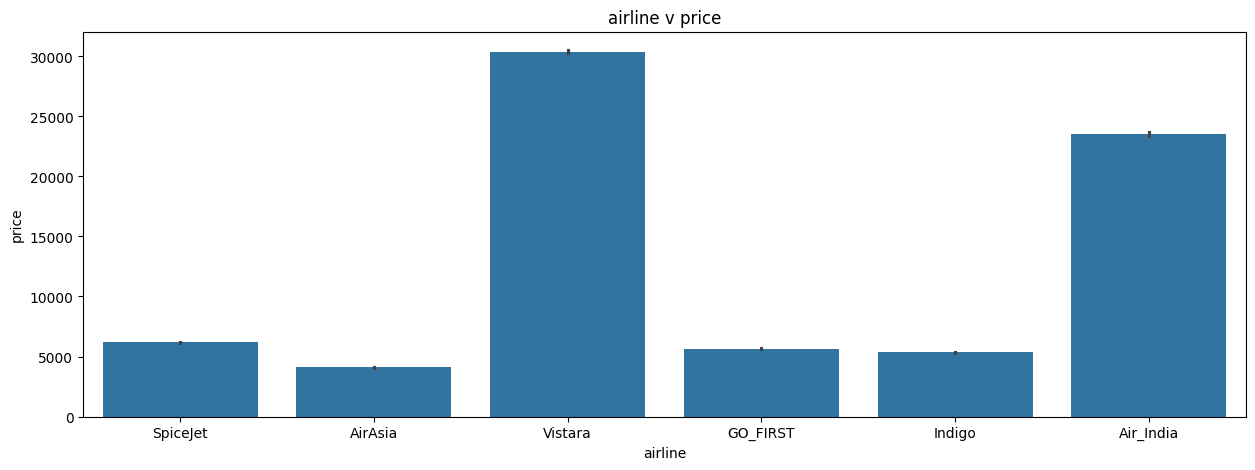

In [ ]:
# Airline vs Price
plt.figure(figsize = (15,5))
sns.barplot(x = df['airline'], y = df['price'])
plt.title('airline v price')
plt.show()

<Axes: >

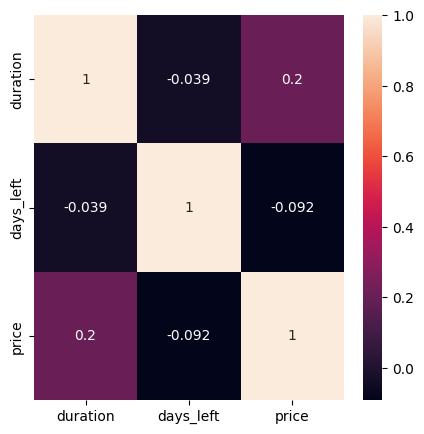

In [ ]:
# Correlation Heatmap
plt.figure(figsize = (5,5)) # Heatmap can only work with numerical data
sns.heatmap(df.select_dtypes(include = np.number).corr(), annot = True)

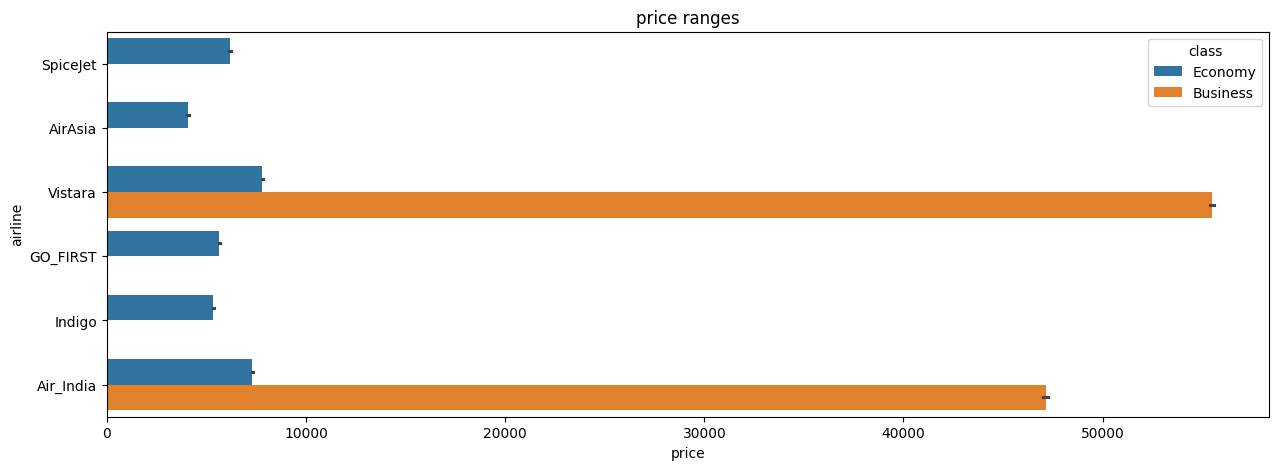

In [ ]:
# Economy vs Business Prices
plt.figure(figsize=(15, 5))
sns.barplot(x ='price', y ='airline',hue ='class', data = df )
plt.title('price ranges')
plt.show()

In [ ]:
# Price Range Analysis
print(f"Economy Class Price Range: ${df[df['class'] == 'Economy']['price'].min():.2f} - ${df[df['class'] == 'Economy']['price'].max():.2f}")
print(f"Business Class Price Range: ${df[df['class'] == 'Business']['price'].min():.2f} - ${df[df['class'] == 'Business']['price'].max():.2f}")

Economy Class Price Range: $1105.00 - $42349.00
Business Class Price Range: $12000.00 - $123071.00


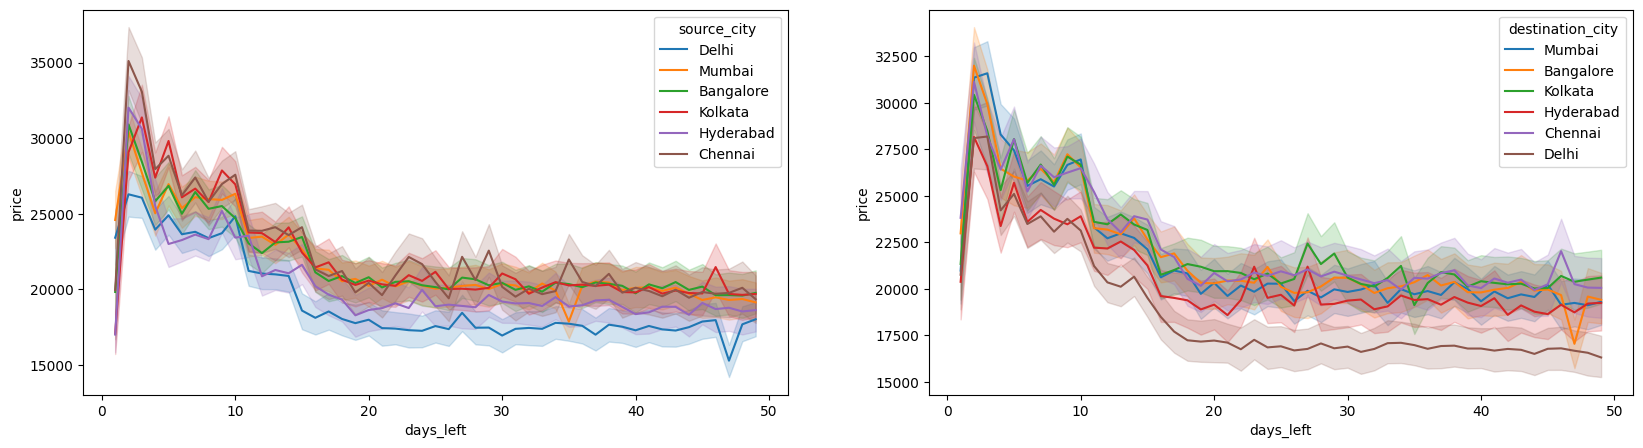

In [ ]:
# Days Left vs Price
fig, ax = plt.subplots(1,2, figsize =(20, 5))
sns.lineplot(x ='days_left', y ='price', hue ='source_city', data = df, ax = ax[0])
sns.lineplot(x = 'days_left', y ='price', hue ='destination_city', data = df, ax = ax[1])
plt.show()

##Label Encoding

In [ ]:
le = LabelEncoder()

In [ ]:
for i in df.columns:
  if df[i].dtype == 'object':
    df[i] = le.fit_transform(df[i])

<Axes: >

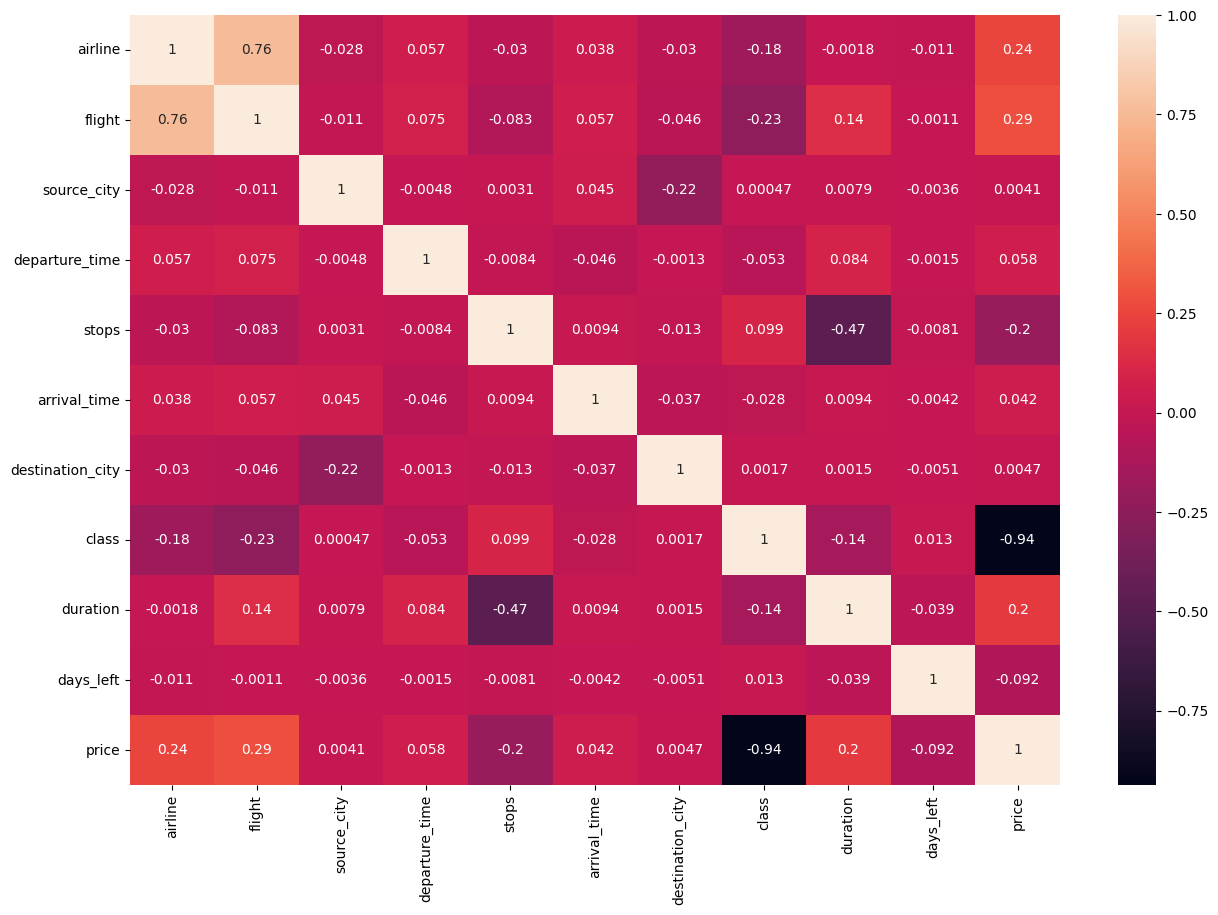

In [ ]:
# Encoded Correlation Matrix
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(), annot = True)

In [ ]:
# Features and Target
x = df.drop(columns = ['price'])
y = df['price']

In [ ]:
# Feature Scaling
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

## VIF : Checking correlation of one column with all the other columns

In [ ]:
# VIF Analysis
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_values = []

for i in range(len(x.columns)):
  vif = variance_inflation_factor(x_scaled, i)
  vif_values.append(vif)

vif_data['VIF'] = vif_values


In [ ]:
vif_data

,feature,VIF
0,airline,2.431596
1,flight,2.524865
2,source_city,1.055612
3,departure_time,1.016583
4,stops,1.293928
5,arrival_time,1.009203
6,destination_city,1.056234
7,class,1.073859
8,duration,1.361168
9,days_left,1.003077


In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [ ]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
# Linear Regression Model
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Price Prediction
model_pred = model.predict(x_test)

In [ ]:
# Model Evaluation

In [ ]:
print(r2_score(y_test, model_pred))

0.9044453825964086


In [ ]:
# Mean Squared Error
mean_squared_error(y_test, model_pred)

49394506.97798127

In [ ]:
# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, model_pred))
rmse

np.float64(7028.122578468681)

# Linear Regression Analysis

Linear Regression was used to predict flight ticket prices.

The model analyzes multiple factors such as:
- Airline
- Flight Class
- Source City
- Destination City
- Days Left

The model achieved a good R2 score,
indicating that it can explain a large portion
of the variation in flight prices.

This project demonstrates:
- Data preprocessing
- Feature engineering
- Data visualization
- Regression modeling
- Price prediction
